In [17]:
import numpy as np
import yfinance as yf 
import matplotlib.pyplot as plt 
import pandas as pd
import pandas_ta as ta
import torch

start_date = '2024-01-01'
end_date = '2025-04-06'
sp500 = yf.Ticker("SPY").history(start=start_date, end=end_date)
sp500 = sp500.drop(columns=['Dividends', 'Stock Splits','Capital Gains'])
print(sp500.tail())


                                 Open        High         Low       Close  \
Date                                                                        
2025-03-31 00:00:00-04:00  549.830017  560.710022  546.869995  559.390015   
2025-04-01 00:00:00-04:00  557.450012  562.940002  553.679993  560.969971   
2025-04-02 00:00:00-04:00  555.049988  567.419983  554.809998  564.520020   
2025-04-03 00:00:00-04:00  545.109985  547.969971  536.700012  536.700012   
2025-04-04 00:00:00-04:00  523.669983  525.869995  505.059998  505.279999   

                              Volume  
Date                                  
2025-03-31 00:00:00-04:00   95328200  
2025-04-01 00:00:00-04:00   54609600  
2025-04-02 00:00:00-04:00   76014500  
2025-04-03 00:00:00-04:00  125986000  
2025-04-04 00:00:00-04:00  216189500  


In [19]:
# We can use pandas to calculate the moving average for different time periods
sp500['50ma'] = sp500['Close'].rolling(window=20).mean()
sp500['200ma'] = sp500['Close'].rolling(window=50).mean()

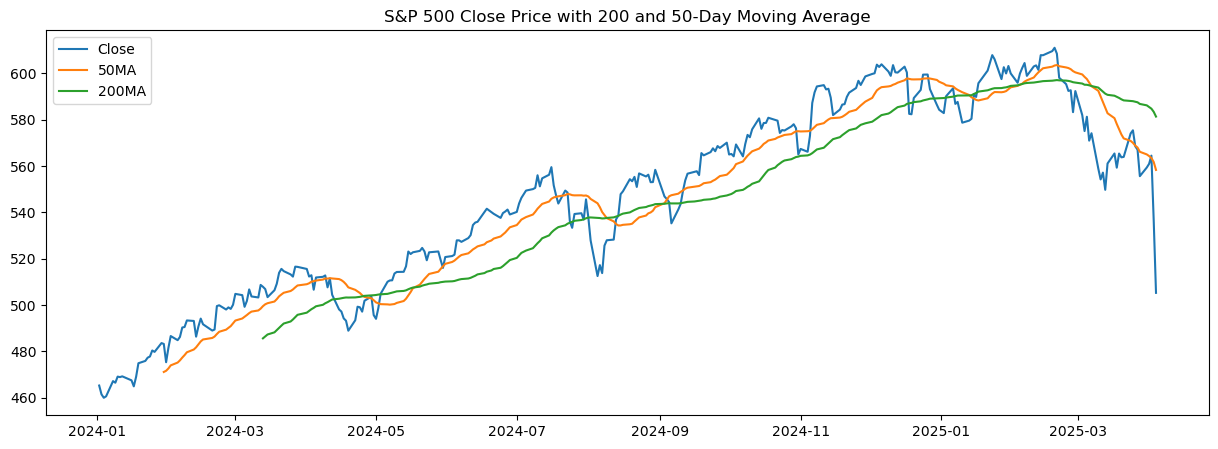

In [21]:
# Let's plot the data to see the moving averages
plt.figure(figsize=(15, 5))
plt.title('S&P 500 Close Price with 200 and 50-Day Moving Average')
plt.plot(sp500['Close'])
plt.plot(sp500['50ma'])
plt.plot(sp500['200ma'])
plt.legend(['Close', '50MA', '200MA'])
plt.show()

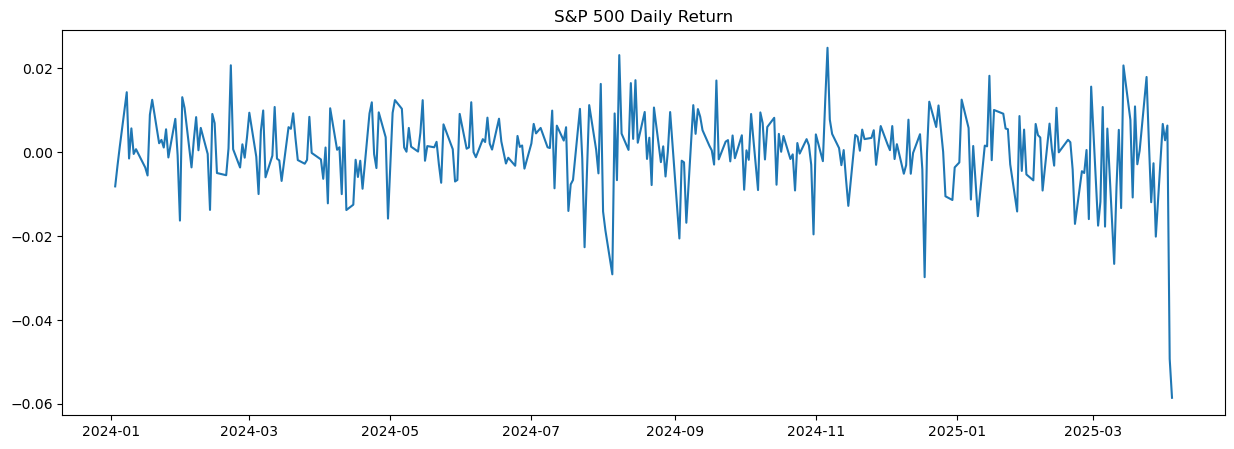

In [23]:
# Calculate the daily return of the close price
sp500['return'] = sp500['Close'].pct_change()

# Plot the daily return
plt.figure(figsize=(15, 5))
plt.title('S&P 500 Daily Return')
plt.plot(sp500['return'])
plt.show()

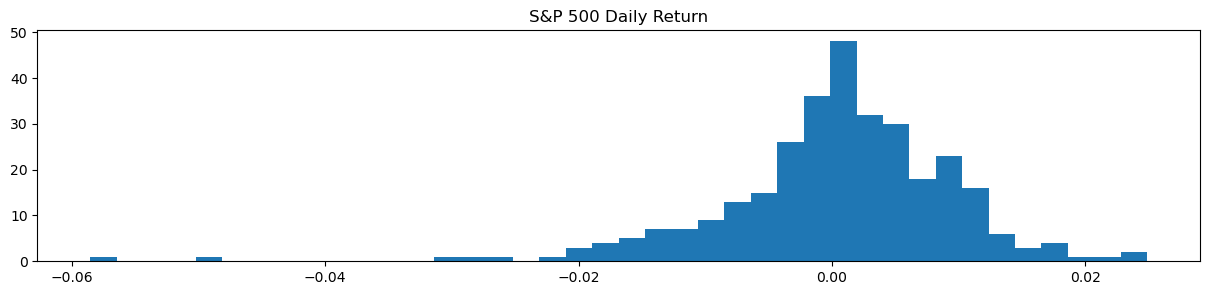

In [25]:
# Plot the daily return using an histogram
plt.figure(figsize=(15, 3))
plt.title('S&P 500 Daily Return')
sp500['return'].hist(bins=40, grid=False)
plt.show()

In [27]:
# Calculate the volatility of the close price
sp500['volatility'] = sp500['return'].rolling(window=50).std() * (50 ** 0.5)

# Calculate the rolling correlation between the return and volatility
sp500['corr252'] = sp500['return'].rolling(window=50).corr(sp500['volatility'])


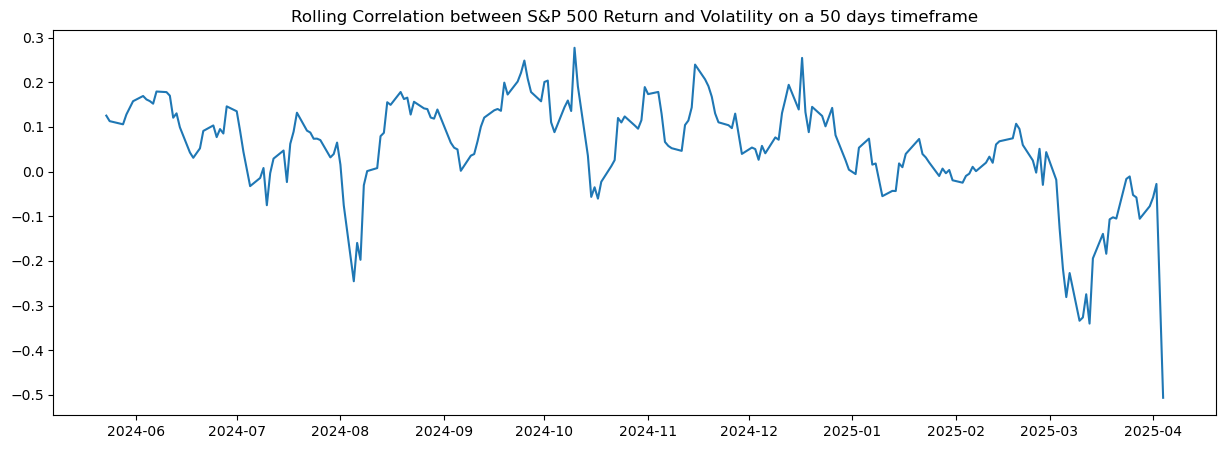

In [29]:
# Calculate the rolling correlation between the return and volatility using a window size of 50 trading days
sp500['corr50'] = sp500['return'].rolling(window=50).corr(sp500['volatility'])

# Plot the rolling correlation
plt.figure(figsize=(15, 5))
plt.title('Rolling Correlation between S&P 500 Return and Volatility on a 50 days timeframe')
plt.plot(sp500['corr50'])
plt.show()

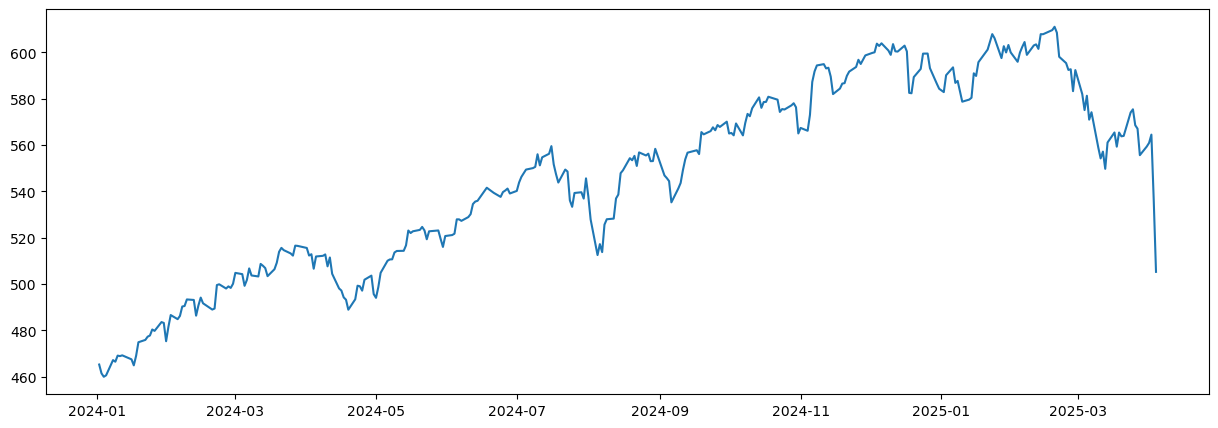

In [31]:
plt.figure(figsize=(15, 5))
plt.plot(sp500['Close'])

In [33]:
data = pd.DataFrame(sp500)
data

,Open,High,Low,Close,Volume,50ma,200ma,return,volatility,corr252,corr50
Date,,,,,,,,,,,
2024-01-02 00:00:00-05:00,464.782010,466.268424,463.138092,465.264343,123623700,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 00:00:00-05:00,463.079049,463.827183,460.854384,461.464691,103585900,NaN,NaN,-0.008167,NaN,NaN,NaN
2024-01-04 00:00:00-05:00,460.982292,463.600730,459.751824,459.978241,84232200,NaN,NaN,-0.003221,NaN,NaN,NaN
2024-01-05 00:00:00-05:00,460.184973,463.088888,459.141539,460.608276,86060800,NaN,NaN,0.001370,NaN,NaN,NaN
2024-01-08 00:00:00-05:00,461.110298,467.331549,460.982325,467.183899,74879100,NaN,NaN,0.014276,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 00:00:00-04:00,549.830017,560.710022,546.869995,559.390015,95328200,565.055463,586.236383,0.006713,0.073847,-0.077528,-0.077528
2025-04-01 00:00:00-04:00,557.450012,562.940002,553.679993,560.969971,54609600,564.347467,585.540027,0.002824,0.073095,-0.057764,-0.057764
2025-04-02 00:00:00-04:00,555.049988,567.419983,554.809998,564.520020,76014500,563.507904,584.805601,0.006328,0.072742,-0.027713,-0.027713


In [35]:
rsi = data.ta.rsi(close='Close', length=14, append=True)
rsi

Date
2024-01-02 00:00:00-05:00          NaN
2024-01-03 00:00:00-05:00          NaN
2024-01-04 00:00:00-05:00          NaN
2024-01-05 00:00:00-05:00          NaN
2024-01-08 00:00:00-05:00          NaN
                               ...    
2025-03-31 00:00:00-04:00    41.179940
2025-04-01 00:00:00-04:00    42.458501
2025-04-02 00:00:00-04:00    45.333839
2025-04-03 00:00:00-04:00    31.886809
2025-04-04 00:00:00-04:00    23.432812
Name: RSI_14, Length: 316, dtype: float64

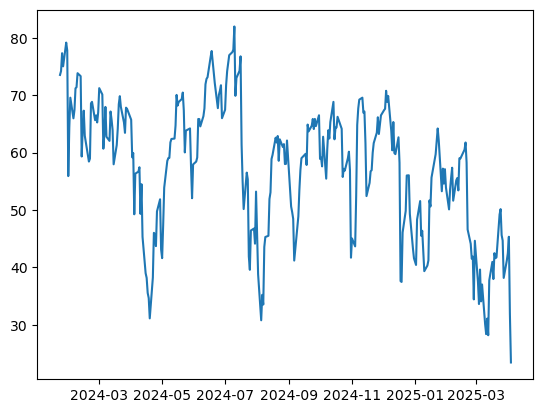

In [37]:
plt.plot(rsi)


In [39]:
indicators = data.ta.rsi(close='Close', length=14, append=True, signal_indicators=True, xa=70, xb=40)


In [41]:
# calculate RSI
data["RSI"] = ta.rsi(data["Close"], length=14, show=False, xa=70, xb=40)
data = data.dropna()
data

,Open,High,Low,Close,Volume,50ma,200ma,return,volatility,corr252,corr50,RSI_14,RSI_14_A_70,RSI_14_B_40,RSI
Date,,,,,,,,,,,,,,,
2024-05-23 00:00:00-04:00,526.262003,526.370606,518.125509,519.349976,57211200,512.389568,508.904615,-0.007304,0.050036,0.125281,0.125281,60.031076,0,0,60.031076
2024-05-24 00:00:00-04:00,521.216150,523.605780,520.258369,522.786194,41258400,513.435254,509.222271,0.006616,0.050344,0.112959,0.112959,63.823836,0,0,63.823836
2024-05-28 00:00:00-04:00,523.605852,523.842826,520.485532,523.151611,36269600,514.410344,509.616849,0.000699,0.049758,0.105848,0.105848,64.212751,0,0,64.212751
2024-05-29 00:00:00-04:00,519.073454,520.682974,518.767353,519.488159,45190300,515.601184,509.878321,-0.007003,0.050073,0.127801,0.127801,57.534728,0,0,57.534728
2024-05-30 00:00:00-04:00,517.928144,518.599591,514.778232,516.042114,46468500,516.700200,510.014586,-0.006634,0.050309,0.142667,0.142667,52.051058,0,0,52.051058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 00:00:00-04:00,549.830017,560.710022,546.869995,559.390015,95328200,565.055463,586.236383,0.006713,0.073847,-0.077528,-0.077528,41.179940,0,0,41.179940
2025-04-01 00:00:00-04:00,557.450012,562.940002,553.679993,560.969971,54609600,564.347467,585.540027,0.002824,0.073095,-0.057764,-0.057764,42.458501,0,0,42.458501
2025-04-02 00:00:00-04:00,555.049988,567.419983,554.809998,564.520020,76014500,563.507904,584.805601,0.006328,0.072742,-0.027713,-0.027713,45.333839,0,0,45.333839


In [43]:
data["RSI"]

Date
2024-05-23 00:00:00-04:00    60.031076
2024-05-24 00:00:00-04:00    63.823836
2024-05-28 00:00:00-04:00    64.212751
2024-05-29 00:00:00-04:00    57.534728
2024-05-30 00:00:00-04:00    52.051058
                               ...    
2025-03-31 00:00:00-04:00    41.179940
2025-04-01 00:00:00-04:00    42.458501
2025-04-02 00:00:00-04:00    45.333839
2025-04-03 00:00:00-04:00    31.886809
2025-04-04 00:00:00-04:00    23.432812
Name: RSI, Length: 217, dtype: float64

In [ ]:
# Import necessary libraries
from plotly.subplots import make_subplots # type: ignore
import plotly.graph_objects as go # type: ignore

# Create Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_width=[0.25, 0.75])

# Inspect Result
print(fig)



# add close price plot
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], name='Close'),
            row=1, col=1)

# Create Candlestick chart for price data
#fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red',
    showlegend=False
))
fig.update_layout(xaxis_rangeslider_visible=False)

In [ ]:
# add RSI plot
fig.add_trace(go.Scatter(x=data.index, y=data["RSI"], name='RSI'),
                row=1, col=1)

In [ ]:
# add red dots for RSI above 70
fig.add_trace(go.Scatter(x=data[data['RSI'] > 70].index,
                         y=data[data['RSI'] > 70]['Close'],
                         mode='markers',
                         marker=dict(size=8, color='red'),
                         name='RSI above 70',
                         showlegend=False),
              row=1, col=1)


In [ ]:
# add green dots for RSI below 30
fig.add_trace(go.Scatter(x=data[data['RSI'] < 30].index,
                         y=data[data['RSI'] < 30]['Close'],
                         mode='markers',
                         marker=dict(size=8, color='green'),
                         name='RSI below 30',
                         showlegend=False),
              row=1, col=1)

# update layout
fig.update_layout(title=f"{'S&P 500'} Close Price and RSI", showlegend=True)

In [ ]:
data['Close'].plot(figsize= (15,5))
plt.grid()

In [ ]:
data['RSI'].plot(figsize= (15,2))
plt.grid()
plt.axhline(y=70, color='r', linestyle='-')
plt.axhline(y=40, color='r', linestyle='-')